In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>
.output_scroll {
    height: auto !important;
    max-height: none !important;
}
</style>
"""))

In [2]:
from dotenv import load_dotenv
load_dotenv()

from langchain_mistralai import ChatMistralAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI

In [3]:
def get_llm(
    model: str = "mistral-small-latest",
    temperature: float = 0.0,
    max_retries: int = 2,
):
    """
    Creates and returns an LLM instance.
    """
    return ChatMistralAI(
        model=model,
        temperature=temperature,
        max_retries=max_retries
    )
   

In [ ]:
def build_evaluator_prompt():
    return ChatPromptTemplate.from_messages(
        [
            (
                "system",
                """
You are a strict mathematics exam evaluator.

Input:
1. OCR student answer.
2. Correct reference answer.
3. Maximum marks.

Core Rules:
- Evaluate ONLY what is written.
- Do NOT assume missing steps.
- Do NOT infer unstated reasoning.
- Award marks strictly for visible valid steps.
- Keep step descriptions very short.
- Total marks must be exact.

Working Requirement Policy (MANDATORY):

1. If the reference solution clearly requires multiple steps 
   (e.g., use of identities, logarithm laws, algebraic rearrangement,
   substitution, integration steps, derivations),

   AND the student provides ONLY a final answer without meaningful steps,

   THEN:
   - Award 0 marks.
   - Set evaluation as empty list.
   - Do not give 1 marks for that step also award 0 mark onlyyy.
   - Set critical_mistake = "No working shown for multi-step problem".

2. If the problem is naturally single-step 
   (simple evaluation or direct known value),
   then direct answer is acceptable.

3. Do NOT guess copying.
   Only judge based on presence or absence of required working.

If a major conceptual or numerical mistake exists,
describe it briefly. Otherwise return empty string.

Return STRICT JSON only:

{{
  "evaluation": [
    {{
      "step": "short step",
      "correct": true,
      "obtained_marks": number
    }}
  ],
  "total_obtained_marks": number,
  "total_marks": number,
  "critical_mistake": "brief description or empty string"
}}
"""
            ),
            (
                "human",
                """
OCR Answer:
{ocr_text}

Reference Answer:
{original_answer}

Maximum Marks: {max_marks}
"""
            ),
        ]
    )

In [5]:
def evaluate_answer(
    ocr_text: str,
    original_answer: str,
    max_marks: int,
    llm=None
):
    """
    Evaluates a student's OCR answer and returns STRICT JSON output.
    """

    if llm is None:
        llm = get_llm()

    prompt = build_evaluator_prompt()
    chain = prompt | llm

    response = chain.invoke(
        {
            "ocr_text": ocr_text,
            "original_answer": original_answer,
            "max_marks": max_marks
        }
    )

    return response.content

In [6]:
llm = get_llm()

Displaying PDF pages as images:


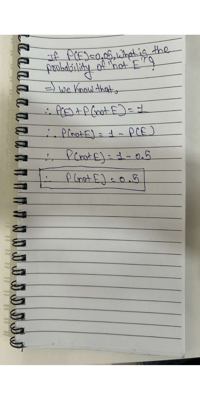

In [7]:
from pdf2image import convert_from_path
from IPython.display import display
print("Displaying PDF pages as images:")

pages = convert_from_path("probability_1.pdf")

for page in pages:
    resized = page.resize((200, 400))  # width, height in pixels
    display(resized)

In [11]:
ocr_text = r"""
If $P(E)=0.05$, what is the probability of "not $E$ "?
⇒ we know that,
$$
\begin{aligned}
& \therefore P(E)+P(\text { not } E)=1 \\
& \therefore P(\text { not } E)=1-P(E) \\
& \therefore P(\text { not } E)=1-0.05 \\
& \therefore P(\text { not } E)=0.95
\end{aligned}
$$
"""

original_answer = r"""
          Step 1: The probability of 'not E' is given by 1 - P(E)\n
          Step 2: Given P(E) = 0.05\n
          Step 3: Calculate 1 - 0.05 = 0.95\n
          Final Answer: 0.95"
"""
max_marks = 10

result = evaluate_answer(
    ocr_text=ocr_text,
    original_answer=original_answer,
    max_marks=max_marks,
    llm = llm,
)

print(result)

```json
{
  "evaluation": [
    {
      "step": "Step 1: Understanding the complement rule",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Step 2: Applying the complement rule",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Step 3: Substituting the given probability",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Step 4: Performing the subtraction",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Final Answer",
      "correct": true,
      "obtained_marks": 2
    }
  ],
  "total_obtained_marks": 10,
  "total_marks": 10,
  "critical_mistake": ""
}
```
